# RESULTS

In this file we are going to evaluate the results. We will start by checking the performance of each group of features regarding the predictions we achieve with all the combinations of them, and looking at what metrics each grup increases. Based on that we will define our final group of features, so our final model.

The last step will consist on evaluate this model by checking the feature importance, the shap values and finally showing some examples of the performance of the model, and the general performance in both the hard onset countries and the protracted ones. 

In [92]:
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, precision_recall_curve, f1_score, roc_auc_score, average_precision_score, precision_score, recall_score, confusion_matrix
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from panelsplit.cross_validation import PanelSplit
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import ipywidgets as widgets
import joblib

In [93]:
# Define the exact path where the file was saved
file_path = "results/experiments_map.json"

# Open the file in read mode ('r') and load it
with open(file_path, "r", encoding="utf-8") as f:
    experiments_map = json.load(f)

experiments_map["Random Benchmark (Stratified)"] = "benchmark_random"
experiments_map["Optimal"] = "optimal"
experiments_map["Best"] = "best"

# Perfect! Your dictionary is now fully recovered
print(f"Experiments map loaded successfully. Total experiments: {len(experiments_map)}")

Experiments map loaded successfully. Total experiments: 73


### 1. RESULTS ANALYSIS BASED ON FEATURES GROUPS

In [94]:
def evaluate_experiments(plots_filter, df_master, threshold_05=False, results_folder="results", experiments_map=None):
    """
    Evaluates ML experiments, plots 6 curves (Global, Protracted, Hard Onset),
    calculates subgroup metrics, and displays ONE single global legend at the bottom without overlapping.
    """
    comparison_results = []
    
    # Prepare the graphics
    fig, axes = plt.subplots(3, 2, figsize=(18, 35))
    ax_roc_glob, ax_pr_glob = axes[0]
    ax_roc_pro, ax_pr_pro = axes[1]
    ax_roc_hard, ax_pr_hard = axes[2]

    for name, prefix in experiments_map.items():
        if name not in plots_filter:
            continue

        pred_file = os.path.join(results_folder, f"{prefix}_predictions.csv")
        feat_file = os.path.join(results_folder, f"{prefix}_feature_importance.csv")
        
        if not os.path.exists(pred_file):
            continue
            
        print(f"Processing: {name}...")
        
        # Load predictions
        df_preds = pd.read_csv(pred_file)

        if 'Unnamed: 0' in df_preds.columns and 'Unnamed: 1' in df_preds.columns:
            df_preds = df_preds.rename(columns={'Unnamed: 0': 'iso3', 'Unnamed: 1': 'month'})
        
        if 'month' in df_preds.columns:
            df_preds['month'] = pd.to_datetime(df_preds['month'], errors='coerce')

        all_y_true = df_preds["y_true"]
        all_y_prob = df_preds["y_prob"]

        # Optimize threshold based on F1 score if not using 0.5
        if threshold_05:
            current_threshold = 0.5
        else:
            precisions, recalls, thresholds_pr = precision_recall_curve(all_y_true, all_y_prob)
            f1_scores = np.divide(
                2 * (precisions * recalls),
                (precisions + recalls),
                out=np.zeros_like(precisions),
                where=(precisions + recalls) != 0
            )
            best_idx = np.argmax(f1_scores[:-1])
            current_threshold = thresholds_pr[best_idx]

        df_preds['y_pred'] = (all_y_prob >= current_threshold).astype(int)

        # Global metrics
        f1 = f1_score(all_y_true, df_preds['y_pred'])
        prec = precision_score(all_y_true, df_preds['y_pred'], zero_division=0)
        rec = recall_score(all_y_true, df_preds['y_pred'])
        roc_auc = roc_auc_score(all_y_true, all_y_prob)
        num_features = len(pd.read_csv(feat_file)) if os.path.exists(feat_file) else 0

        # Subgroup metrics initialization
        pro_prec, pro_rec, pro_f1, pro_roc_auc = np.nan, np.nan, np.nan, np.nan
        hard_prec, hard_rec, hard_f1, hard_roc_auc = np.nan, np.nan, np.nan, np.nan
        has_subgroups = False
        
        if 'is_protracted' not in df_preds.columns:
            if 'iso3' in df_preds.columns and 'month' in df_preds.columns:
                df_preds = pd.merge(df_preds, df_master[['iso3', 'month', 'is_protracted']], on=['iso3', 'month'], how='inner')

        if 'is_protracted' in df_preds.columns and not df_preds['is_protracted'].isna().all():
            has_subgroups = True
        
        # Plotting ROC and PR curves
        fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
        ax_roc_glob.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
        
        prec_curve, rec_curve, _ = precision_recall_curve(all_y_true, all_y_prob)
        avg_prec = average_precision_score(all_y_true, all_y_prob)
        ax_pr_glob.plot(rec_curve, prec_curve, lw=2, label=f'{name} (AP = {avg_prec:.3f})')

        if has_subgroups:
            # Protracted crises
            pro_mask = df_preds['is_protracted'] == 1
            if pro_mask.sum() > 0:
                y_t_pro = df_preds.loc[pro_mask, 'y_true']
                y_p_pro = df_preds.loc[pro_mask, 'y_prob']
                y_pred_pro = df_preds.loc[pro_mask, 'y_pred']
                
                pro_prec = precision_score(y_t_pro, y_pred_pro, zero_division=0)
                pro_rec = recall_score(y_t_pro, y_pred_pro, zero_division=0)
                pro_f1 = f1_score(y_t_pro, y_pred_pro, zero_division=0)
                
                if len(np.unique(y_t_pro)) > 1:
                    pro_roc_auc = roc_auc_score(y_t_pro, y_p_pro)
                    fpr_p, tpr_p, _ = roc_curve(y_t_pro, y_p_pro)
                    ax_roc_pro.plot(fpr_p, tpr_p, lw=2) 
                    
                    prec_p, rec_p, _ = precision_recall_curve(y_t_pro, y_p_pro)
                    ax_pr_pro.plot(rec_p, prec_p, lw=2)

            # Hard onset crises
            hard_mask = df_preds['is_protracted'] == 0
            if hard_mask.sum() > 0:
                y_t_hard = df_preds.loc[hard_mask, 'y_true']
                y_p_hard = df_preds.loc[hard_mask, 'y_prob']
                y_pred_hard = df_preds.loc[hard_mask, 'y_pred']
                
                hard_prec = precision_score(y_t_hard, y_pred_hard, zero_division=0)
                hard_rec = recall_score(y_t_hard, y_pred_hard, zero_division=0)
                hard_f1 = f1_score(y_t_hard, y_pred_hard, zero_division=0)
                
                if len(np.unique(y_t_hard)) > 1:
                    hard_roc_auc = roc_auc_score(y_t_hard, y_p_hard)
                    fpr_h, tpr_h, _ = roc_curve(y_t_hard, y_p_hard)
                    ax_roc_hard.plot(fpr_h, tpr_h, lw=2)
                    
                    prec_h, rec_h, _ = precision_recall_curve(y_t_hard, y_p_hard)
                    ax_pr_hard.plot(rec_h, prec_h, lw=2)

        # Save results for comparison
        comparison_results.append({
            'Experiment': name,
            'Thr': round(current_threshold, 3),
            'Glob F1': round(f1, 3),
            'Glob P': round(prec, 3),
            'Glob R': round(rec, 3),
            'Glob AUC': round(roc_auc, 3),
            'Pro F1': round(pro_f1, 3) if pd.notna(pro_f1) else '-',
            'Pro P': round(pro_prec, 3) if pd.notna(pro_prec) else '-',
            'Pro R': round(pro_rec, 3) if pd.notna(pro_rec) else '-',
            'Pro AUC': round(pro_roc_auc, 3) if pd.notna(pro_roc_auc) else '-',
            'Hard F1': round(hard_f1, 3) if pd.notna(hard_f1) else '-',
            'Hard P': round(hard_prec, 3) if pd.notna(hard_prec) else '-',
            'Hard R': round(hard_rec, 3) if pd.notna(hard_rec) else '-',
            'Hard AUC': round(hard_roc_auc, 3) if pd.notna(hard_roc_auc) else '-',
            'Feats': num_features
        })


    plot_configs = [
        (ax_roc_glob, ax_pr_glob, 'GLOBAL'),
        (ax_roc_pro, ax_pr_pro, 'PROTRACTED CRISES (is_protracted = 1)'),
        (ax_roc_hard, ax_pr_hard, 'HARD ONSET CRISES (is_protracted = 0)')
    ]
    
    for ax_roc, ax_pr, title in plot_configs:
        ax_roc.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.5)
        ax_roc.set_xlim([0.0, 1.0])
        ax_roc.set_ylim([0.0, 1.05])
        ax_roc.set_title(f'{title}: ROC Curve', fontsize=14, fontweight='bold')
        ax_roc.set_xlabel('False Positive Rate', fontsize=11)
        ax_roc.set_ylabel('True Positive Rate', fontsize=11)
        ax_roc.grid(alpha=0.3)

        ax_pr.set_xlim([0.0, 1.0])
        ax_pr.set_ylim([0.0, 1.05])
        ax_pr.set_title(f'{title}: Precision-Recall Curve', fontsize=14, fontweight='bold')
        ax_pr.set_xlabel('Recall', fontsize=11)
        ax_pr.set_ylabel('Precision', fontsize=11)
        ax_pr.grid(alpha=0.3)

    handles, labels = ax_roc_glob.get_legend_handles_labels()
    
    plt.tight_layout(rect=[0, 0.25, 1, 1])
    
    fig.legend(
        handles, 
        labels, 
        loc='upper center',       
        bbox_to_anchor=(0.5, 0.23),
        ncol=3,                  
        fontsize=9, 
        frameon=True,
        facecolor='#f9f9f9',
        edgecolor='#d3d3d3'
    )

    plt.show()

    # Print final ranking of experiments based on Global F1 score
    if comparison_results:
        df_results = pd.DataFrame(comparison_results).sort_values(by='Glob F1', ascending=False)
        print("\n" + "#"*160)
        print("FINAL RANKING (SORTED BY GLOBAL F1)".center(160))
        print("#"*160)
        print(df_results.to_string(index=False))
    else:
        print("\nNo experiments were successfully loaded.")

All the available models that we have, and that we can check their performance are:

In [95]:
models = list(experiments_map.keys())

In [96]:
print(models)

['Signals (CERF)', 'INFORM', 'INFORM + Signals (CERF)', 'Risk Alerts', 'Risk Alerts + Signals (CERF)', 'Risk Alerts + INFORM', 'Risk Alerts + INFORM + Signals (CERF)', 'Risk Alerts BEST', 'Risk Alerts BEST + Signals (CERF)', 'Risk Alerts BEST + INFORM', 'Risk Alerts BEST + INFORM + Signals (CERF)', 'Derived Humanitarian Impact', 'Derived Humanitarian Impact + Signals (CERF)', 'Derived Humanitarian Impact + INFORM', 'Derived Humanitarian Impact + INFORM + Signals (CERF)', 'Derived Humanitarian Impact + Risk Alerts', 'Derived Humanitarian Impact + Risk Alerts + Signals (CERF)', 'Derived Humanitarian Impact + Risk Alerts + INFORM', 'Derived Humanitarian Impact + Risk Alerts + INFORM + Signals (CERF)', 'Derived Humanitarian Impact + Risk Alerts BEST', 'Derived Humanitarian Impact + Risk Alerts BEST + Signals (CERF)', 'Derived Humanitarian Impact + Risk Alerts BEST + INFORM', 'Derived Humanitarian Impact + Risk Alerts BEST + INFORM + Signals (CERF)', 'Derived Humanitarian Impact BEST', 'Der

Plotting the comparison of all the possible combinations:

Processing: Signals (CERF)...
Processing: INFORM...
Processing: INFORM + Signals (CERF)...
Processing: Risk Alerts...
Processing: Risk Alerts + Signals (CERF)...
Processing: Risk Alerts + INFORM...
Processing: Risk Alerts + INFORM + Signals (CERF)...
Processing: Risk Alerts BEST...
Processing: Risk Alerts BEST + Signals (CERF)...
Processing: Risk Alerts BEST + INFORM...
Processing: Risk Alerts BEST + INFORM + Signals (CERF)...
Processing: Derived Humanitarian Impact...
Processing: Derived Humanitarian Impact + Signals (CERF)...
Processing: Derived Humanitarian Impact + INFORM...
Processing: Derived Humanitarian Impact + INFORM + Signals (CERF)...
Processing: Derived Humanitarian Impact + Risk Alerts...
Processing: Derived Humanitarian Impact + Risk Alerts + Signals (CERF)...
Processing: Derived Humanitarian Impact + Risk Alerts + INFORM...
Processing: Derived Humanitarian Impact + Risk Alerts + INFORM + Signals (CERF)...
Processing: Derived Humanitarian Impact + Risk Alerts BEST...
Pro

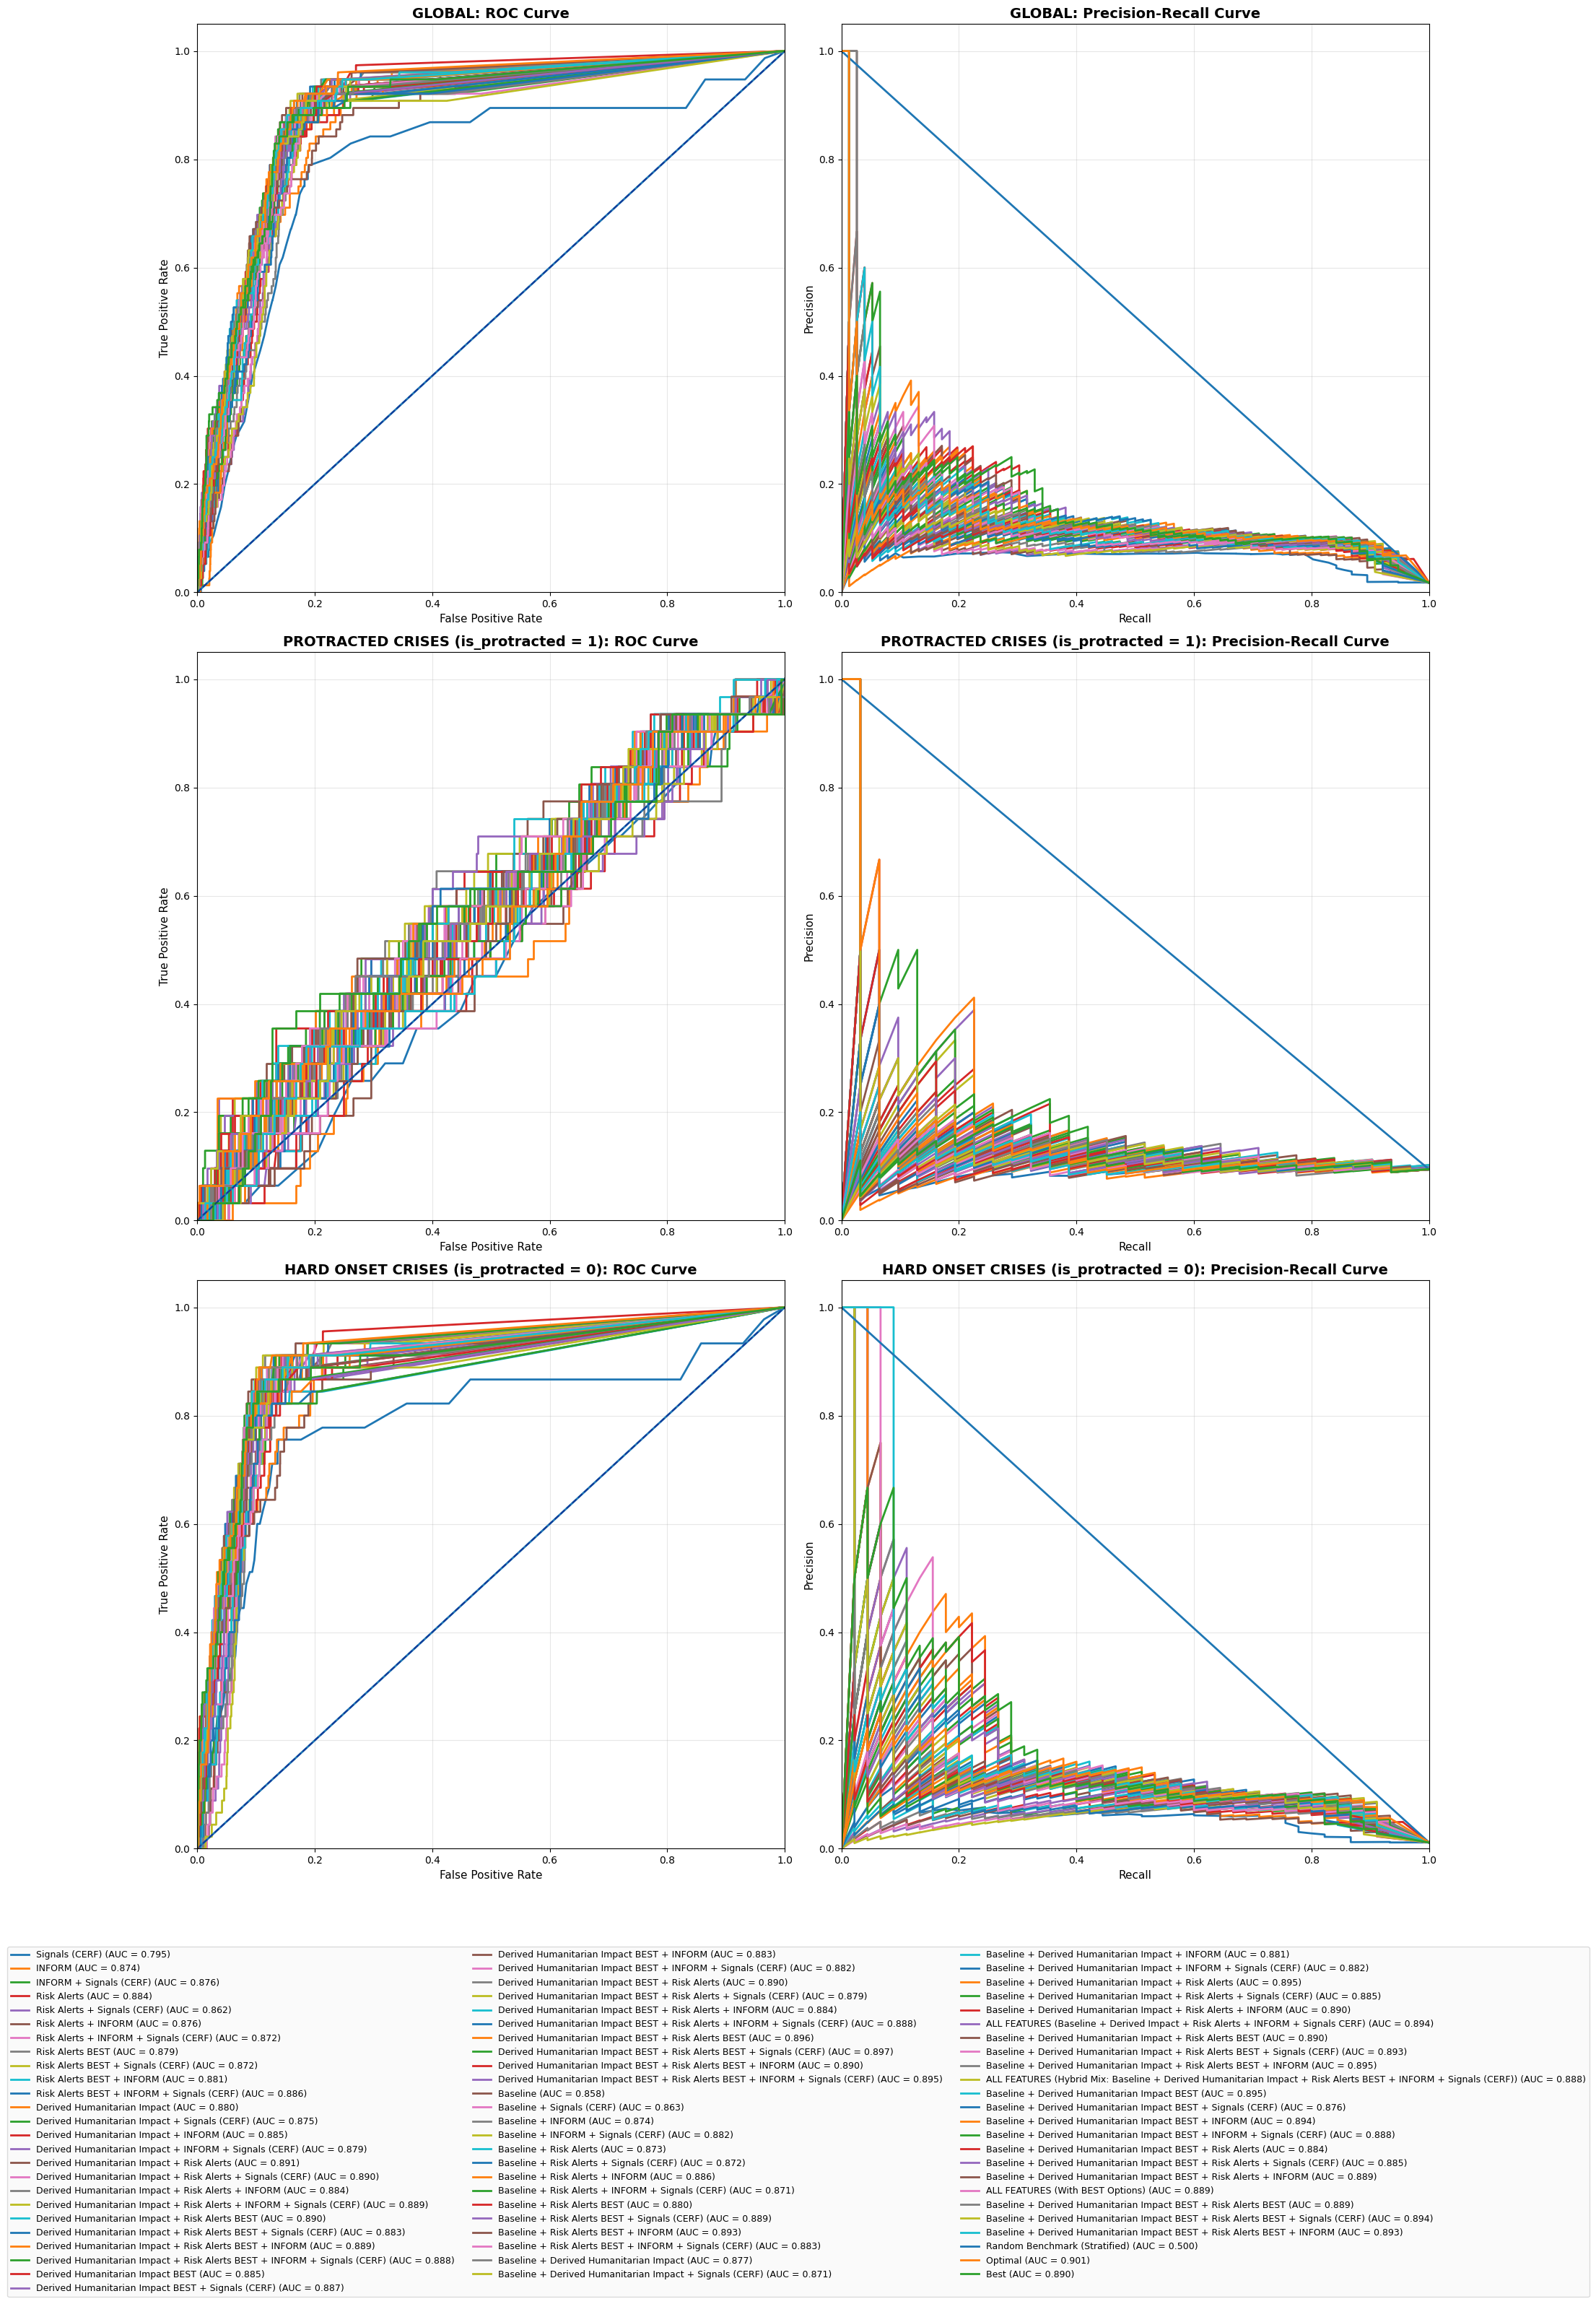


################################################################################################################################################################
                                                              FINAL RANKING (SORTED BY GLOBAL F1)                                                               
################################################################################################################################################################
                                                                                                    Experiment   Thr  Glob F1  Glob P  Glob R  Glob AUC  Pro F1  Pro P  Pro R  Pro AUC  Hard F1  Hard P  Hard R  Hard AUC  Feats
                                                                                                          Best 0.772    0.269   0.227   0.329     0.890   0.258  0.194  0.387    0.581    0.280   0.271   0.289     0.892     30
                                                                  

In [139]:
ruta_parquet = "../data_clean/final_data.parquet" 
df_original = pd.read_parquet(ruta_parquet)

if 'iso3' not in df_original.columns:
    df_original = df_original.reset_index()
if 'month' in df_original.columns:
    df_original['month'] = pd.to_datetime(df_original['month'], errors='coerce')


evaluate_experiments(
    plots_filter=models, 
    df_master=df_original,
    threshold_05=False, 
    experiments_map=experiments_map
)

### 2. CHOOSING THE FINAL MODEL (FINAL GROUP OF FEATURES)

We have decided that our final model is the one containing the following features. The thing is that we have seen that INFORM, Derived Humanitarian Impact, and Cerf Signals are super usefull (the first two models have two out of these 3 grupos of features). Also we see that the one with Derived Humanitarian Impact + INFORM has more precision, and the one with Derived Humanitarian Impact BEST + Signals (CERF) have more recall, so we think that joining them has to be usefull. Also, regarding the risk variables, we see that including risk variables in general increases the recall, which is our main target, so even though we are not ading all the blok because it causes curse of dimensionality, we think that adding the main two variables is going to help the model increase the recall.

In [65]:
best_features_derived_humanitarian_impact = ['disp_6m_avg', 'rolling_3m_displacements', 'disp_3m_avg', 'fatalities_lag1', 'lethality_rate', 'fat_3m_avg', 'fat_6m_avg', 'acled_disp_score_max', 'fatalities_lag2', 'acled_disp_score_mean', 'conflict_severity_index', 'acled_semantic_intensity', 'disp_change_lag2_to_now', 'disp_per_event', 'disp_per_fatality']
features_cerf_signals =  ['p_sig1', 'p_sig2', 'p_sig3', 'protracted_signal', 'h_sig1', 'h_sig2', 'hard_onset_signal']

FINAL_FEATURES = best_features_derived_humanitarian_impact + ['INFORM'] + features_cerf_signals + ['risk_3', 'risk_12']
TARGET_COL = 'target_2m'

In [66]:
ruta_parquet = "../data_clean/final_data.parquet" 
df_original = pd.read_parquet(ruta_parquet)

In [67]:
RESULTS_FOLDER = "results"
FILE_PREFIX = "rf_baseline"

MODEL_PARAMS = {
    'n_estimators': 200,
    'max_depth': 10,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1
}

os.makedirs(RESULTS_FOLDER, exist_ok=True)

# DATA PREPARATION FOR CROSS-VALIDATION
df_cv_prep = df_original.copy()

# Hide the latest 2 months per country to handle target reporting lag
last_2_months_mask = df_cv_prep.groupby(level='iso3').cumcount(ascending=False) < 2
df_cv_prep[TARGET_COL] = df_cv_prep[TARGET_COL].astype(float)
df_cv_prep.loc[last_2_months_mask, TARGET_COL] = np.nan

# Keep only the needed columns and drop rows with missing data (NaNs)
cols_to_keep = FINAL_FEATURES + [TARGET_COL]
df_cv_clean = df_cv_prep[cols_to_keep].dropna()

# Separate features, targets, and time/country trackers
X_cv = df_cv_clean[FINAL_FEATURES]
y_cv = df_cv_clean[TARGET_COL]
periods_cv = df_cv_clean.index.get_level_values('month')

# CROSS-VALIDATION LOOP (PANEL SPLIT)
print("\n" + "="*60)
print(f"RUNNING CROSS-VALIDATION (Features count: {len(FINAL_FEATURES)})")
print("="*60)

panel_split = PanelSplit(periods=periods_cv, n_splits=24, test_size=1, gap=1)
clf_cv = RandomForestClassifier(**MODEL_PARAMS)

all_y_true = []
all_y_prob = []
all_iso3 = []
all_months = []

for train_idx, test_idx in panel_split.split(X_cv):
    # Slice arrays using iloc positionally
    X_train, X_test = X_cv.iloc[train_idx], X_cv.iloc[test_idx]
    y_train, y_test = y_cv.iloc[train_idx], y_cv.iloc[test_idx]
    
    # Train and predict out-of-sample probabilities
    clf_cv.fit(X_train, y_train)
    probs = clf_cv.predict_proba(X_test)[:, 1]
    
    # Store results
    all_y_true.extend(y_test.values)
    all_y_prob.extend(probs)
    all_iso3.extend(X_test.index.get_level_values('iso3'))
    all_months.extend(X_test.index.get_level_values('month'))

# OPTIMAL THRESHOLD OPTIMIZATION & SAVING PREDICTIONS

# Calculate the F1-maximizing threshold over all combined validation outputs
precisions, recalls, thresholds = precision_recall_curve(all_y_true, all_y_prob)
f1_scores = np.divide(
    2 * (precisions * recalls),
    (precisions + recalls),
    out=np.zeros_like(precisions),
    where=(precisions + recalls) != 0
)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

# Create the final predictions DataFrame
df_preds = pd.DataFrame({
    'iso3': all_iso3,
    'month': all_months,
    'y_true': all_y_true,
    'y_prob': all_y_prob
})

# Map binary predictions using the optimized threshold
df_preds['optimal_threshold'] = best_threshold
df_preds['y_pred'] = (df_preds['y_prob'] >= best_threshold).astype(int)

# Export predictions to CSV
pred_path = os.path.join(RESULTS_FOLDER, f"{FILE_PREFIX}_predictions.csv")
df_preds.to_csv(pred_path, index=False)

print(f"🎯 Optimal Threshold calculated: {best_threshold:.4f}")
print(f"Saved predictions dataframe to: {pred_path}")

# EXPORT FEATURE IMPORTANCE FROM CV
df_feat = pd.DataFrame({
    'feature': X_cv.columns,
    'importance': clf_cv.feature_importances_
}).sort_values(by='importance', ascending=False)

feat_path = os.path.join(RESULTS_FOLDER, f"{FILE_PREFIX}_feature_importance.csv")
df_feat.to_csv(feat_path, index=False)
print(f"Saved feature importance matrix to: {feat_path}")

# Print performance overview
final_f1 = f1_score(all_y_true, df_preds['y_pred'])
final_auc = roc_auc_score(all_y_true, all_y_prob)
print(f"CV Metrics -> F1 (at optimal thr): {final_f1:.3f} | AUC: {final_auc:.3f}")

# TRAINING FINAL MODEL (100% OF HISTORICAL DATA)
print("\n" + "="*60)
print("TRAINING FINAL PRODUCTION MODEL (100% of historical data)")
print("="*60)

df_final_prep = df_original.copy()

# Apply the same 2-month reporting lag mask
last_2_months_mask_full = df_final_prep.groupby(level='iso3').cumcount(ascending=False) < 2
df_final_prep[TARGET_COL] = df_final_prep[TARGET_COL].astype(float)
df_final_prep.loc[last_2_months_mask_full, TARGET_COL] = np.nan

# Clean rows
df_final_clean = df_final_prep[FINAL_FEATURES + [TARGET_COL]].dropna()

X_full = df_final_clean[FINAL_FEATURES]
y_full = df_final_clean[TARGET_COL]

# Fit final model instance
model_final = RandomForestClassifier(**MODEL_PARAMS)
model_final.fit(X_full, y_full)

model_path = os.path.join(RESULTS_FOLDER, f"{FILE_PREFIX}_final_model.joblib")
joblib.dump(model_final, model_path)

print(f"Final model successfully trained on all {len(X_full)} historical panel samples.")
print("The 'model_final' object is ready for SHAP values extraction.")


RUNNING CROSS-VALIDATION (Features count: 25)
🎯 Optimal Threshold calculated: 0.8085
Saved predictions dataframe to: results/rf_baseline_predictions.csv
Saved feature importance matrix to: results/rf_baseline_feature_importance.csv
CV Metrics -> F1 (at optimal thr): 0.351 | AUC: 0.906

TRAINING FINAL PRODUCTION MODEL (100% of historical data)
Final model successfully trained on all 15859 historical panel samples.
The 'model_final' object is ready for SHAP values extraction.


Before stablishing the final model, we will do some hyperparameter tunning to see if we can improve the model:

In [71]:
# Data Preparation 
def prepare_final_data(df, features_to_use, target_col='target_2m'):
    df_temp = df.copy()
    
    last_2_months_mask = df_temp.groupby('iso3').cumcount(ascending=False) < 2
    df_temp[target_col] = df_temp[target_col].astype(float)
    df_temp.loc[last_2_months_mask, target_col] = np.nan

    df_model = df_temp[features_to_use + [target_col, 'is_protracted']].dropna()
    
    X = df_model[features_to_use]
    y = df_model[target_col]
    subgroups = df_model['is_protracted'] 
    
    return X, y, subgroups


X, y, subgroups = prepare_final_data(df_original, FINAL_FEATURES, TARGET_COL)
periods = X.index.get_level_values('month')


panel_split = PanelSplit(periods=periods, n_splits=24, test_size=1, gap=1)
cv_splits = list(panel_split.split(X))

# HYPERPARAMETER TUNING 
print("Starting Hyperparameter Tuning...")

# Define the hyperparameter search space
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
}

# Base model for RandomizedSearchCV
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# Aleatory search (more efficient than GridSearchCV) optimizing the F1-Score
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=9,           
    scoring='average_precision',        
    cv=cv_splits,        
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X, y)
best_params = random_search.best_params_

print(f"Best Parameters:\n{best_params}\n")

# Validation with the best hyperparameters
print("Evaluating the model with the optimal parameters...")

# Instanciamos el modelo con los hiperparámetros ganadores
clf_cv = RandomForestClassifier(**best_params, class_weight='balanced', random_state=42, n_jobs=-1)

all_y_true, all_y_prob, all_iso3, all_months, all_subgroups = [], [], [], [], []

for train_idx, test_idx in cv_splits:
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    clf_cv.fit(X_train, y_train)
    probs = clf_cv.predict_proba(X_test)[:, 1]
    
    all_y_true.extend(y_test.values)
    all_y_prob.extend(probs)
    all_iso3.extend(X_test.index.get_level_values('iso3'))
    all_months.extend(X_test.index.get_level_values('month'))
    all_subgroups.extend(subgroups.iloc[test_idx].values)

df_eval = pd.DataFrame({
    'iso3': all_iso3,
    'month': all_months,
    'y_true': all_y_true,
    'y_prob': all_y_prob,
    'is_protracted': all_subgroups
})

# Compute the optimal threshold based on F1 score
precisions, recalls, thresholds = precision_recall_curve(df_eval['y_true'], df_eval['y_prob'])
f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls), out=np.zeros_like(precisions), where=(precisions + recalls) != 0)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[np.argmax(f1_scores[:-1])]
best_f1 = f1_scores[best_idx]

# Asign predictions based on the best threshold
df_eval['y_pred'] = (df_eval['y_prob'] >= best_threshold).astype(int)
print(f"Best threshold: {best_threshold:.4f}")
print(f"F1-Score at optimal threshold: {best_f1:.4f}")

Starting Hyperparameter Tuning...
Fitting 24 folds for each of 9 candidates, totalling 216 fits
Best Parameters:
{'n_estimators': 100, 'max_depth': 10}

Evaluating the model with the optimal parameters...
Best threshold: 0.7928
F1-Score at optimal threshold: 0.3444


As we can see, by doing hyperparameter tunning we don't achieve a better performance, so we will define our model as the one with the default parameters.

### 3. EVALUATING THE FINAL MODEL

We add the predictions to the original dataset, to create a finals dataset with all the information:

In [74]:
min_month = df_preds['month'].min()

df_original_test = df_original[df_original.index.get_level_values('month') >= min_month].copy()
df_preds_indexed = df_preds.set_index(['iso3', 'month'])
df_final_test = df_original_test.join(df_preds_indexed, how='left')

# Quick check
print(f"Test period starts at: {min_month}")
print(f"Rows in df_original_test: {len(df_original_test)}")
print(f"Rows in df_final_test: {len(df_final_test)}")

Test period starts at: 2024-03-01 00:00:00
Rows in df_original_test: 4576
Rows in df_final_test: 4576


#### 3.1 METRICS EVALUATION

In [76]:
def print_subgroup_metrics(df):
    # Drop rows without predictions or true values
    df_clean = df.dropna(subset=['y_true', 'y_pred', 'y_prob']).copy()
    
    if df_clean.empty:
        print("No valid predictions to evaluate.")
        return

    thr = df_clean['optimal_threshold'].iloc[0]
    print(f" Optimal Threshold: {thr:.3f}\n" + "-"*50)
    
    subsets = {
        'GLOBAL': df_clean,
        'PROTRACTED (is_protracted = 1)': df_clean[df_clean['is_protracted'] == 1],
        'HARD ONSET (is_protracted = 0)': df_clean[df_clean['is_protracted'] == 0]
    }
    
    for name, sub_df in subsets.items():
        if len(sub_df) == 0: continue
        y_t = sub_df['y_true']
        y_p = sub_df['y_pred']
        y_prob = sub_df['y_prob']
        
        f1 = f1_score(y_t, y_p, zero_division=0)
        prec = precision_score(y_t, y_p, zero_division=0)
        rec = recall_score(y_t, y_p, zero_division=0)
        auc = roc_auc_score(y_t, y_prob) if len(np.unique(y_t)) > 1 else np.nan
        
        print(f"{name}:")
        print(f"   F1-Score: {f1:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | AUC: {auc:.3f}\n")

print_subgroup_metrics(df_final_test)

 Optimal Threshold: 0.808
--------------------------------------------------
GLOBAL:
   F1-Score: 0.351 | Precision: 0.361 | Recall: 0.342 | AUC: 0.906

PROTRACTED (is_protracted = 1):
   F1-Score: 0.400 | Precision: 0.382 | Recall: 0.419 | AUC: 0.672

HARD ONSET (is_protracted = 0):
   F1-Score: 0.313 | Precision: 0.342 | Recall: 0.289 | AUC: 0.888



#### 3.2 FEATURE IMPORTANCE AND SHAP VALUES

In [77]:
df_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model_final.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Feature importance:")
display(df_importance)

Feature importance:


,feature,importance
0,disp_6m_avg,0.172694
24,risk_12,0.115473
6,fat_6m_avg,0.113926
2,disp_3m_avg,0.085573
3,fatalities_lag1,0.081011
23,risk_3,0.079831
5,fat_3m_avg,0.062163
1,rolling_3m_displacements,0.053704
15,INFORM,0.042477
8,fatalities_lag2,0.029027


Computing SHAP values...
New SHAP format detected (3D Array).
Generating Summary Plot...


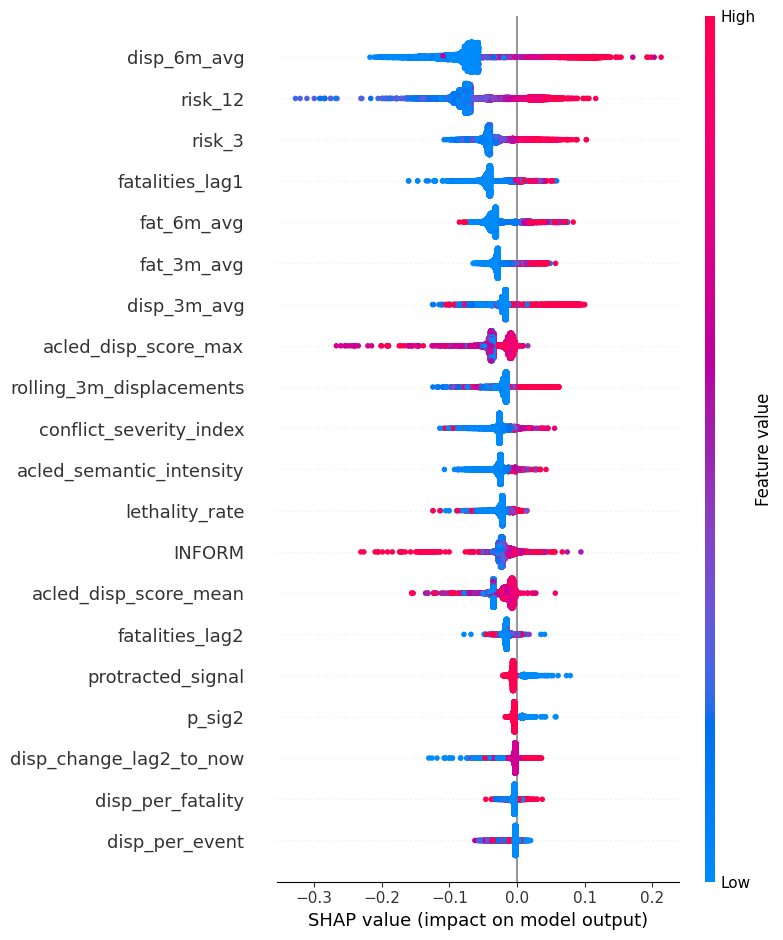

In [78]:
explainer = shap.TreeExplainer(model_final)

# Compute the SHAP values for your matrix X
print("Computing SHAP values...")
shap_values = explainer.shap_values(X)

# Extract the positive class (1) safely
if isinstance(shap_values, list):
    print("Old SHAP format detected (List of arrays).")
    shap_values_positiva = shap_values[1]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    print("New SHAP format detected (3D Array).")
    shap_values_positiva = shap_values[:, :, 1]
else:
    print("Old 2D format detected.")
    shap_values_positiva = shap_values

# Plotting the Summary Plot 
print("Generating Summary Plot...")
shap.summary_plot(shap_values_positiva, X)

#### 3.3 SHOWING EXAMPLES OF THE RESULTS

In [82]:
# Drop rows where we don't have predictions or true values
df_eval = df_final_test.dropna(subset=['y_true', 'y_pred'])

print("FALSE POSITIVES:")
print(len(df_eval[(df_eval['y_pred'] == 1) & (df_eval['y_true'] == 0)]))

print("FALSE NEGATIVES:")
print(len(df_eval[(df_eval['y_pred'] == 0) & (df_eval['y_true'] == 1)]))

print("\n\n================ METRICS REPORT ================\n")
print(classification_report(df_eval['y_true'], df_eval['y_pred']))

FALSE POSITIVES:
46
FALSE NEGATIVES:
50


================ METRICS REPORT ================

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      3984
         1.0       0.36      0.34      0.35        76

    accuracy                           0.98      4060
   macro avg       0.67      0.67      0.67      4060
weighted avg       0.98      0.98      0.98      4060



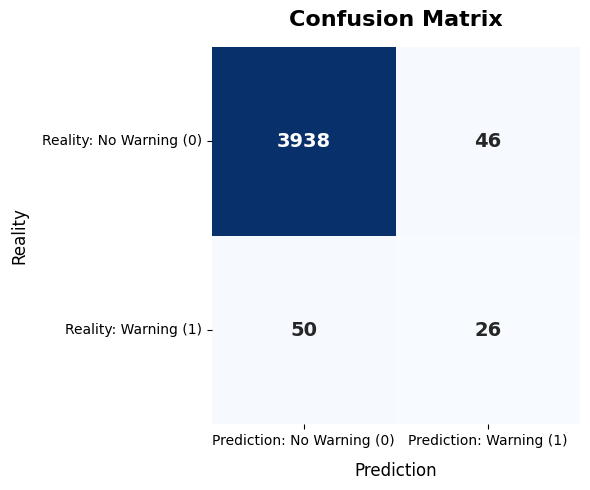

In [85]:
# Comput the confusion matrix
cm = confusion_matrix(df_eval['y_true'], df_eval['y_pred'])


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Prediction: No Warning (0)', 'Prediction: Warning (1)'],
            yticklabels=['Reality: No Warning (0)', 'Reality: Warning (1)'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Prediction', fontsize=12, labelpad=10)
plt.ylabel('Reality', fontsize=12, labelpad=10)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [90]:
df_final_test.reset_index(inplace=True)

In [91]:
def plot_country(country):
    country_df = df_final_test[df_final_test['iso3'] == country].sort_values('month').copy()
    
    # Normalize all variables to 0-1
    for col in ['fatalities', 'monthly_displacement', 'event_count']:
        max_val = country_df[col].max()
        country_df[col + '_norm'] = country_df[col] / max_val if max_val > 0 else 0

    fig, ax1 = plt.subplots(figsize=(14, 6))
    fig.suptitle(f'{country} — Multi-Signal Overview (normalized)', fontsize=13)
    
    ax1.plot(country_df['month'], country_df['fatalities_norm'],
             color='firebrick', linewidth=1.5, label='Fatalities (norm)')
    ax1.plot(country_df['month'], country_df['monthly_displacement_norm'],
             color='purple', linewidth=1.5, label='Displacement (norm)')
    ax1.plot(country_df['month'], country_df['event_count_norm'],
             color='gray', linewidth=1, alpha=0.7, label='Event count (norm)')
    ax1.plot(country_df['month'], country_df['risk_3'],
             color='black', linewidth=1.5, linestyle='--', label='Risk_3')
    ax1.plot(country_df['month'], country_df['INFORM'] / 10,
             color='steelblue', linewidth=1.5, linestyle=':', label='INFORM (norm)')
    

    # True Positives (TP: pred=1 i true=1) -> Green dashed
    true_pos = country_df[(country_df['y_pred'] == 1) & (country_df['y_true'] == 1)]['month']
    for month in true_pos:
        ax1.axvline(x=month, color='green', alpha=0.8, linewidth=2, linestyle='--', label='TP (Encert Crític)')

    # False Positives (FP: pred=1 i true=0) -> Orange dashed
    false_pos = country_df[(country_df['y_pred'] == 1) & (country_df['y_true'] == 0)]['month']
    for month in false_pos:
        ax1.axvline(x=month, color='darkorange', alpha=0.8, linewidth=2, linestyle='--', label='FP (Falsa Alarma)')

    # False Negatives (FN: pred=0 i true=1) -> Red dashed
    false_neg = country_df[(country_df['y_pred'] == 0) & (country_df['y_true'] == 1)]['month']
    for month in false_neg:
        ax1.axvline(x=month, color='red', alpha=0.8, linewidth=2, linestyle='--', label='FN (Crisi no detectada)')

    ax1.set_ylim(0, 1.1)
    ax1.set_ylabel('Normalized value (0-1)')
    ax1.set_xlabel('Month')

    # Allocation-eligible 
    eligible = country_df[country_df['allocation-eligible'] == 1]['month']
    for month in eligible:
        ax1.axvline(x=month, color='red', alpha=0.1, linewidth=15, label='Allocation Eligible')

    # HDX alerts
    hdx_medium = country_df[country_df['hdx_alert_Medium concern'] == True]['month']
    hdx_high = country_df[country_df['hdx_alert_High concern'] == True]['month']
    ax1.scatter(hdx_medium, [1.05]*len(hdx_medium), color='orange', s=60, zorder=5, label='HDX Medium')
    ax1.scatter(hdx_high, [1.05]*len(hdx_high), color='red', s=60, zorder=5, label='HDX High')

    # Delete duplicate legend entries
    handles, labels = ax1.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax1.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=8)
    
    plt.tight_layout()
    plt.show()

countries = sorted(df_final_test['iso3'].unique().tolist())
dropdown = widgets.Dropdown(options=countries, value='AFG', description='Country:')
widgets.interact(plot_country, country=dropdown)

interactive(children=(Dropdown(description='Country:', options=('AFG', 'AGO', 'ALB', 'ARE', 'ARG', 'ARM', 'AUS…

<function __main__.plot_country(country)>

FALTA LA GRAFICA COMPARANDOLO CON LO DE LAS CERF ALLOCATIONS QUE ESTAN EN CLEAN DATA EN CERF_CLEAN?! SERIA MEJOR HACER LA COMPARACION AL PRINCIPIO CON LO TEORICO, NO AHORA PORQUE LAS `REDICCIONES SON EN GENERAL MALAS.

#### 3.4 ROBUSTNESS CHECKS